In [1]:
'''Problem Statement

In large enterprise batch systems managed by AutoSys, job failures and execution delays often cause SLA breaches and manual intervention
by operations teams. The objective of this project is to build a supervised machine learning model that predicts the likelihood of 
an AutoSys job failure or delay using historical job execution data such as CPU usage, memory consumption, dependency delays, 
runtime duration, and previous failure history. This prediction enables proactive remediation and automated self-healing using
automation tools like Ansible.'''

'Problem Statement\n\nIn large enterprise batch systems managed by AutoSys, job failures and execution delays often cause SLA breaches and manual intervention\nby operations teams. The objective of this project is to build a supervised machine learning model that predicts the likelihood of \nan AutoSys job failure or delay using historical job execution data such as CPU usage, memory consumption, dependency delays, \nruntime duration, and previous failure history. This prediction enables proactive remediation and automated self-healing using\nautomation tools like Ansible.'

In [2]:
##Step 1:Import Required Libraries

In [44]:
# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import accuracy_score

In [4]:
#Step 2 — Load the AutoSys Dataset

In [45]:
#Load dataset
df = pd.read_csv("C:/Users/Shrinivas/Desktop/training/code_python/vectordatabase/autosys_dataset_120k.csv")
#showsfirst 5 head
df.head()

,job_name,start_time,cpu_usage_percent,memory_gb,dependency_delay_min,runtime_seconds,previous_failures,status
0,SYNC_JOB_358,3/31/2026 6:51,87,15.51,16,321,3,FAILURE
1,REPORT_JOB_486,3/9/2026 21:26,26,5.35,3,632,1,FAILURE
2,LOAD_JOB_38,3/10/2026 5:24,57,8.62,7,596,1,SUCCESS
3,ETL_JOB_13,2/28/2026 14:48,90,3.17,23,130,3,SUCCESS
4,ETL_JOB_329,2/15/2026 22:46,77,7.39,15,234,3,FAILURE


In [46]:
#Step 3 — Understand Dataset Structure
#check the nummber of rows and columns
df.shape

(1000, 8)

In [47]:
# check the columns
df.columns

Index(['job_name', 'start_time', 'cpu_usage_percent', 'memory_gb',
       'dependency_delay_min', 'runtime_seconds', 'previous_failures',
       'status'],
      dtype='str')

In [48]:
# Check data types
df.dtypes

job_name                    str
start_time                  str
cpu_usage_percent         int64
memory_gb               float64
dependency_delay_min      int64
runtime_seconds           int64
previous_failures         int64
status                      str
dtype: object

In [49]:
#Step 4 — Check Missing Values
# Count missing values
df.isnull().sum()

job_name                0
start_time              0
cpu_usage_percent       0
memory_gb               0
dependency_delay_min    0
runtime_seconds         0
previous_failures       0
status                  0
dtype: int64

In [50]:
# Step 5 — 0

status
SUCCESS    508
FAILURE    492
Name: count, dtype: int64

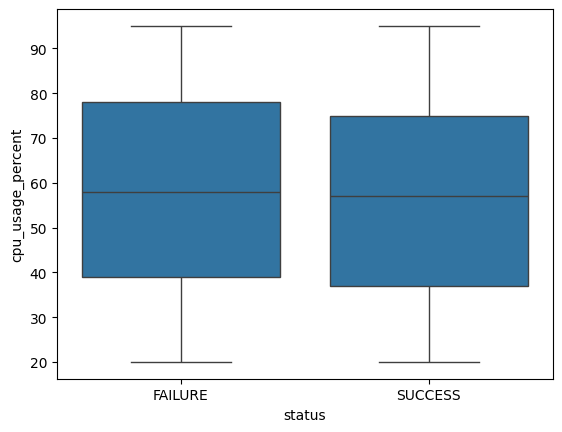

In [51]:
#Step 6 — EDA Visualization
#CPU VS STATUS
sns.boxplot(x='status', y='cpu_usage_percent', data=df)
plt.show()

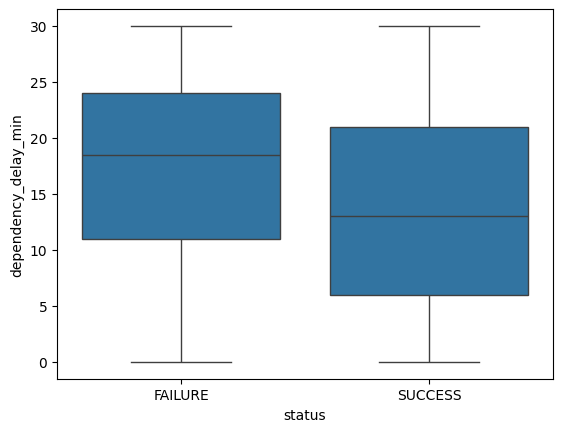

In [52]:
sns.boxplot(x='status', y='dependency_delay_min', data=df)
plt.show()

In [53]:
#Step 7 — Feature Engineering: Convert categorical column status → numeric. Convert SUCCESS / FAILURE to numbers
le = LabelEncoder()

df['status'] = le.fit_transform(df['status'])
print(df['status'])

# SUCCESS = 0
# FAILURE = 1

0      0
1      0
2      1
3      1
4      0
      ..
995    1
996    0
997    1
998    1
999    1
Name: status, Length: 1000, dtype: int64


In [54]:
#Step 8 — Select Features: Remove columns not useful for prediction.
df.head()

,job_name,start_time,cpu_usage_percent,memory_gb,dependency_delay_min,runtime_seconds,previous_failures,status
0,SYNC_JOB_358,3/31/2026 6:51,87,15.51,16,321,3,0
1,REPORT_JOB_486,3/9/2026 21:26,26,5.35,3,632,1,0
2,LOAD_JOB_38,3/10/2026 5:24,57,8.62,7,596,1,1
3,ETL_JOB_13,2/28/2026 14:48,90,3.17,23,130,3,1
4,ETL_JOB_329,2/15/2026 22:46,77,7.39,15,234,3,0


In [55]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
# Import VIF function
from statsmodels.stats.outliers_influence import variance_inflation_factor # Import VIF function


In [57]:
# Feature columns
X = df[['cpu_usage_percent',
        'memory_gb',
        'dependency_delay_min',
        'runtime_seconds',
        'previous_failures']]

# Target variable
y = df['status']

In [58]:
# train/split test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [59]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled, X_test_scaled)
print(y)

print("Data has been standardized.")

[[ 0.6357437  -0.97324291 -1.38932687 -1.169272   -1.49119144]
 [ 0.95378593 -0.08097711  1.1335944  -0.94314679  0.27092548]
 [-0.99990206 -0.49402087  0.5602032   0.88924712  1.44567008]
 ...
 [-0.36381759 -0.81806625  1.59230735 -1.44218173  0.27092548]
 [ 0.13596305  0.78162256 -1.50400511 -0.58056672  1.44567008]
 [-0.90903285  0.6743681  -0.93061391  1.38438334  1.44567008]] [[ 8.62916725e-01  9.07133092e-01  9.04237917e-01  1.34929495e+00
   1.44567008e+00]
 [ 7.26612911e-01  9.93849461e-01  6.74881438e-01 -4.55807985e-01
   1.44567008e+00]
 [ 1.49900119e+00 -4.27842592e-01  1.13359440e+00  4.60388970e-01
  -1.49119144e+00]
 [ 1.40813198e+00 -3.75356368e-01 -1.61868335e+00 -9.74336474e-01
  -9.03819133e-01]
 [-9.12099684e-02 -6.21813417e-01  1.36295087e+00  1.22453622e+00
   1.44567008e+00]
 [-1.54511731e+00 -5.55635136e-01  1.70698559e+00 -4.51909274e-01
   1.44567008e+00]
 [-1.68142112e+00  1.17557731e-01 -1.50400511e+00  5.61755441e-01
  -3.16446829e-01]
 [ 6.35743702e-01 -5.

In [60]:
#Calculate VIF
# Create empty dataframe for results
vif_data = pd.DataFrame()

# Store feature names
vif_data["Feature"] = X.columns

# Calculate VIF for each feature
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(len(X.columns))
]

print(vif_data)

                Feature       VIF
0     cpu_usage_percent  4.996725
1             memory_gb  3.877694
2  dependency_delay_min  3.438279
3       runtime_seconds  3.583929
4     previous_failures  2.763374


In [61]:
#Logistic Regression (Linear)
log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

log_acc = accuracy_score(y_test, log_pred)

In [62]:
# Decision Tree
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

In [63]:
#random forest
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

In [65]:
#SVM
svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, svm_pred)

In [67]:
#KNN
knn_model = KNeighborsClassifier()

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_acc = accuracy_score(y_test, knn_pred)

In [68]:
#step 9 Compare All Models
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "KNN"
    ],
    "Accuracy":[
        log_acc,
        dt_acc,
        rf_acc,
        svm_acc,
        knn_acc
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression     0.595
1        Decision Tree     0.560
2        Random Forest     0.585
3                  SVM     0.600
4                  KNN     0.580


In [69]:
#11:  highest accuracy, so SVM is currently the best model among these.
final_model = SVC()

final_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [71]:
#12: Step 12 Test Final Model

final_pred = final_model.predict(X_test)

final_accuracy = accuracy_score(y_test, final_pred)

print("Final Model Accuracy:", final_accuracy)

Final Model Accuracy: 0.53


In [ ]:
#Step 13 — Predict New AutoSys Job
'''example
| CPU | Memory | Delay | Runtime | Prev Fail |
| --- | ------ | ----- | ------- | --------- |
| 88  | 7      | 12    | 300     | 2         | '''


In [72]:
new_job = [[88,7,12,300,2]]

prediction = final_model.predict(new_job)

print(prediction)

[1]


C:\Users\Shrinivas\Desktop\training\code_python\vectordatabase\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [73]:
new_job = [[88,9,12,500,6]]

prediction = final_model.predict(new_job)

print(prediction)

[0]


C:\Users\Shrinivas\Desktop\training\code_python\vectordatabase\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
